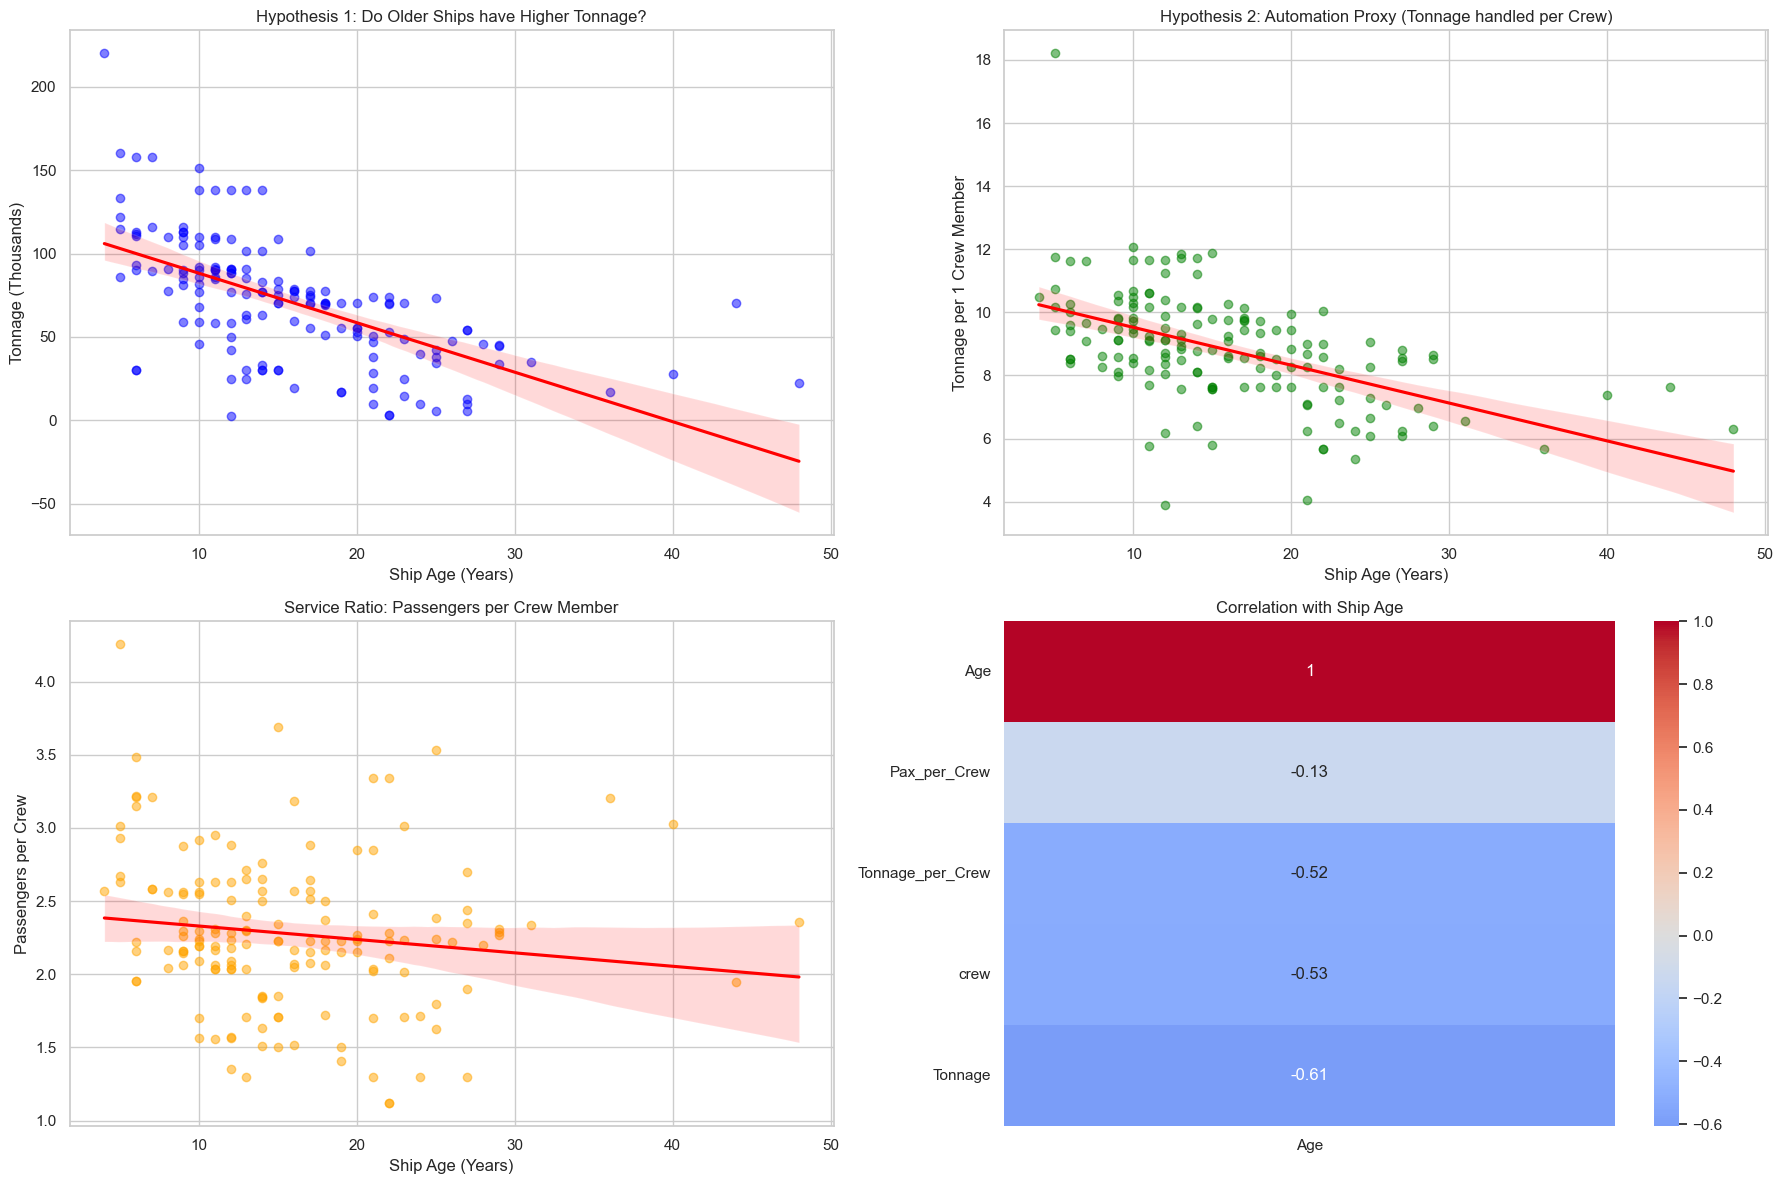

--- 数据验证结论 ---
Age 与 Tonnage 的相关系数: -0.61 (负数表示越年轻船越大)
Age 与 船员效率(Tonnage/Crew) 的相关系数: -0.52 (负数表示越年轻效率越高)


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 加载数据
# 确保你的 CSV 文件路径是正确的
df = pd.read_csv('backend/data/cruise_ship_info.csv')

# 2. 特征工程：构造“效率”与“智能化”的代理指标
# Tonnage_per_Crew: 每个船员负责的吨位。越高说明自动化/效率越高（或者服务越少）。
df['Tonnage_per_Crew'] = df['Tonnage'] / df['crew'] 

# Pax_per_Crew: 每个船员服务的乘客数。越高说明越“省人”。
df['Pax_per_Crew'] = df['passengers'] / df['crew']

# 3. 设置绘图风格
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# --- 图表 A: 验证“老船偏向更大？” ---
# 绘制 Age vs Tonnage
plt.subplot(2, 2, 1)
sns.regplot(data=df, x='Age', y='Tonnage', scatter_kws={'alpha':0.5, 'color':'blue'}, line_kws={'color':'red'})
plt.title('Hypothesis 1: Do Older Ships have Higher Tonnage?')
plt.xlabel('Ship Age (Years)')
plt.ylabel('Tonnage (Thousands)')

# --- 图表 B: 验证“新船船员少（智能化）？” ---
# 我们不看绝对数量，看“每吨位船员效率”
# 如果新船(Age小)的点在Y轴上方，说明单位吨位需要的船员更少（即单人负责更多吨位）
plt.subplot(2, 2, 2)
sns.regplot(data=df, x='Age', y='Tonnage_per_Crew', scatter_kws={'alpha':0.5, 'color':'green'}, line_kws={'color':'red'})
plt.title('Hypothesis 2: Automation Proxy (Tonnage handled per Crew)')
plt.xlabel('Ship Age (Years)')
plt.ylabel('Tonnage per 1 Crew Member')

# --- 图表 C: 船员服务密度 ---
# 看看老船是不是真的“人海战术”
plt.subplot(2, 2, 3)
sns.regplot(data=df, x='Age', y='Pax_per_Crew', scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'red'})
plt.title('Service Ratio: Passengers per Crew Member')
plt.xlabel('Ship Age (Years)')
plt.ylabel('Passengers per Crew')

# --- 图表 D: 相关性热力图 ---
# 用数字说话：红色代表正相关，蓝色代表负相关
plt.subplot(2, 2, 4)
cols = ['Age', 'Tonnage', 'crew', 'Tonnage_per_Crew', 'Pax_per_Crew']
corr = df[cols].corr()
sns.heatmap(corr[['Age']].sort_values(by='Age', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Ship Age')

plt.tight_layout()
plt.show()

# 4. 打印简单的文字结论
print("--- 数据验证结论 ---")
print(f"Age 与 Tonnage 的相关系数: {corr.loc['Age', 'Tonnage']:.2f} (负数表示越年轻船越大)")
print(f"Age 与 船员效率(Tonnage/Crew) 的相关系数: {corr.loc['Age', 'Tonnage_per_Crew']:.2f} (负数表示越年轻效率越高)")